# HistGradientBoostingRegressor — triagem TUO em horizontes selecionados

Este notebook implementa o primeiro modelo tabular não linear da segunda etapa.

## Objetivo

Comparar o `HistGradientBoostingRegressor` com a Ridge TUO nos horizontes `t+1`, `t+3`, `t+6`, `t+12` e `t+24`, separadamente para temperatura e umidade.

## Por que começar com 10 modelos

O `HistGradientBoostingRegressor` produz uma saída por estimador. Uma previsão horária completa de 24 horas e dois alvos exigiria 48 modelos. Nesta triagem são treinados apenas 10 modelos, reduzindo tempo e permitindo decidir, somente com 2024, se há ganho não linear que justifique a expansão para os 48 modelos necessários à API.

## Protocolo

- Configuração de atributos: TUO, selecionada na ablação Ridge.
- Processamento: CPU.
- Treino: 2011–2023, excluindo 2022.
- Seleção de hiperparâmetros: validação de 2024.
- Teste: 2025, consultado somente após a seleção.
- Avaliação adicional: 2026 parcial.
- Entradas: histórico TUO achatado + atributos temporais futuros.
- Sem valores meteorológicos futuros reais nas entradas.
- Métricas finais em °C e pontos percentuais.

## 1. Importações e configuração

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns",100)
pd.set_option("display.width",180)

DIRETORIO_TUO=Path("dados_processados_multivariados/TUO")
DIRETORIO_RIDGE=Path("resultados_modelagem/ablacao_ridge_TU_TUO_TUOV")
DIRETORIO_SAIDA=Path("resultados_modelagem/hist_gradient_boosting_TUO_screening")
DIRETORIO_SAIDA.mkdir(parents=True,exist_ok=True)

SPLITS=["treino","validacao","teste","avaliacao_2026"]
HORIZONTES=[1,3,6,12,24]
ALVOS={0:("temperatura_c","°C"),1:("umidade_pct","p.p.")}
SEMENTE=42

# Grade curta e conservadora para caber no prazo.
CONFIGURACOES_HGB=[
 {"nome":"hgb_A","learning_rate":0.08,"max_iter":150,"max_leaf_nodes":15,"min_samples_leaf":30,"l2_regularization":1.0},
 {"nome":"hgb_B","learning_rate":0.05,"max_iter":250,"max_leaf_nodes":31,"min_samples_leaf":30,"l2_regularization":1.0},
 {"nome":"hgb_C","learning_rate":0.05,"max_iter":250,"max_leaf_nodes":15,"min_samples_leaf":60,"l2_regularization":5.0},
]

print("Processamento definido: CPU")
print("Triagem: 5 horizontes × 2 alvos = 10 modelos por configuração")
print("Configurações candidatas:",len(CONFIGURACOES_HGB))

Processamento definido: CPU
Triagem: 5 horizontes × 2 alvos = 10 modelos por configuração
Configurações candidatas: 3


## 2. Carregamento dos artefatos TUO

In [2]:
obrigatorios=[DIRETORIO_TUO/f"{s}.npz" for s in SPLITS]+[DIRETORIO_TUO/"scaler_y.joblib",DIRETORIO_TUO/"metadados.json"]
faltantes=[str(p) for p in obrigatorios if not p.exists()]
if faltantes: raise FileNotFoundError("Arquivos ausentes:"+chr(10)+chr(10).join(faltantes))

splits={}
for s in SPLITS:
 with np.load(DIRETORIO_TUO/f"{s}.npz") as arq: splits[s]={k:arq[k] for k in arq.files}
scaler_y=joblib.load(DIRETORIO_TUO/"scaler_y.joblib")
with (DIRETORIO_TUO/"metadados.json").open(encoding="utf-8") as f: meta_preparacao=json.load(f)
assert meta_preparacao["configuracao"]=="TUO"
assert meta_preparacao["usa_covariaveis_meteorologicas_futuras"] is False
print(meta_preparacao["colunas_meteorologicas_historicas"])
print(meta_preparacao["contagens"])

['temperatura_ar_horaria_c', 'umidade_horaria_pct', 'temperatura_ponto_orvalho_c']
{'treino': 84744, 'validacao': 7837, 'teste': 7970, 'avaliacao_2026': 4551}


## 3. Matriz tabular e alvos nas unidades originais

O HGB não precisa de padronização do alvo. As entradas já preparadas são usadas como atributos tabulares; os alvos são transformados de volta para °C e pontos percentuais antes do treinamento. Cada estimador aprende um par específico `alvo × horizonte`.

In [3]:
def preparar_X(split):
 hist=split["X_historico"].reshape(len(split["X_historico"]),-1)
 fut=split["X_futuro_temporal"].reshape(len(split["X_futuro_temporal"]),-1)
 return np.concatenate([hist,fut],axis=1).astype(np.float32,copy=False)

def inverter_y(y_norm):
 forma=y_norm.shape
 return scaler_y.inverse_transform(y_norm.reshape(-1,2)).reshape(forma)

X={s:preparar_X(splits[s]) for s in SPLITS}
y={s:inverter_y(splits[s]["y"]) for s in SPLITS}
for s in SPLITS: print(s,X[s].shape,y[s].shape)
assert X["treino"].shape[1]==264
assert all(np.isfinite(X[s]).all() and np.isfinite(y[s]).all() for s in SPLITS)

treino (84744, 264) (84744, 24, 2)
validacao (7837, 264) (7837, 24, 2)
teste (7970, 264) (7970, 24, 2)
avaliacao_2026 (4551, 264) (4551, 24, 2)


## 4. Grade de hiperparâmetros

A triagem treina 30 estimadores: três configurações, cinco horizontes e dois alvos. A parada antecipada usa uma fração interna do próprio treino. A seleção externa continua sendo feita exclusivamente com 2024.

In [4]:
resultados=[]
modelos_candidatos={}

for cfg in CONFIGURACOES_HGB:
 print(chr(10)+"="*76); print("CONFIGURAÇÃO",cfg["nome"],cfg); print("="*76)
 for h in HORIZONTES:
  hi=h-1
  for j,(alvo,unidade) in ALVOS.items():
   print(f"Treinando {cfg['nome']} | {alvo} | t+{h}...")
   modelo=HistGradientBoostingRegressor(
    loss="squared_error",learning_rate=cfg["learning_rate"],max_iter=cfg["max_iter"],
    max_leaf_nodes=cfg["max_leaf_nodes"],min_samples_leaf=cfg["min_samples_leaf"],
    l2_regularization=cfg["l2_regularization"],early_stopping=True,validation_fraction=0.1,
    n_iter_no_change=15,tol=1e-5,random_state=SEMENTE)
   t0=time.perf_counter(); modelo.fit(X["treino"],y["treino"][:,hi,j]); tempo=time.perf_counter()-t0
   pred_tr=modelo.predict(X["treino"]); pred_val=modelo.predict(X["validacao"])
   mae_tr=mean_absolute_error(y["treino"][:,hi,j],pred_tr)
   mae_val=mean_absolute_error(y["validacao"][:,hi,j],pred_val)
   resultados.append({"configuracao":cfg["nome"],"horizonte_horas":h,"indice_alvo":j,"alvo":alvo,"unidade":unidade,
    "mae_treino":mae_tr,"mae_validacao":mae_val,"rmse_validacao":mean_squared_error(y["validacao"][:,hi,j],pred_val)**0.5,
    "vies_validacao":float(np.mean(pred_val-y["validacao"][:,hi,j])),"tempo_segundos":tempo,"n_iter_":modelo.n_iter_})
   modelos_candidatos[(cfg["nome"],h,j)]=modelo
   print(f"  concluído em {tempo:.1f}s | iterações={modelo.n_iter_} | treino={mae_tr:.3f} {unidade} | validação={mae_val:.3f} {unidade}")

resultados=pd.DataFrame(resultados)
display(resultados)


CONFIGURAÇÃO hgb_A {'nome': 'hgb_A', 'learning_rate': 0.08, 'max_iter': 150, 'max_leaf_nodes': 15, 'min_samples_leaf': 30, 'l2_regularization': 1.0}
Treinando hgb_A | temperatura_c | t+1...
  concluído em 4.3s | iterações=150 | treino=0.462 °C | validação=0.526 °C
Treinando hgb_A | umidade_pct | t+1...
  concluído em 3.5s | iterações=150 | treino=2.408 p.p. | validação=2.495 p.p.
Treinando hgb_A | temperatura_c | t+3...
  concluído em 3.6s | iterações=150 | treino=0.849 °C | validação=0.975 °C
Treinando hgb_A | umidade_pct | t+3...
  concluído em 3.4s | iterações=150 | treino=4.356 p.p. | validação=4.653 p.p.
Treinando hgb_A | temperatura_c | t+6...
  concluído em 4.1s | iterações=150 | treino=1.178 °C | validação=1.364 °C
Treinando hgb_A | umidade_pct | t+6...
  concluído em 3.6s | iterações=150 | treino=5.862 p.p. | validação=6.523 p.p.
Treinando hgb_A | temperatura_c | t+12...
  concluído em 3.6s | iterações=150 | treino=1.477 °C | validação=1.735 °C
Treinando hgb_A | umidade_pct |

,configuracao,horizonte_horas,indice_alvo,alvo,unidade,mae_treino,mae_validacao,rmse_validacao,vies_validacao,tempo_segundos,n_iter_
0,hgb_A,1,0,temperatura_c,°C,0.462437,0.526380,0.822977,-0.056142,4.250949,150
1,hgb_A,1,1,umidade_pct,p.p.,2.407755,2.494716,3.869292,0.088297,3.523525,150
2,hgb_A,3,0,temperatura_c,°C,0.848980,0.974552,1.401741,-0.127688,3.595087,150
3,hgb_A,3,1,umidade_pct,p.p.,4.355959,4.653042,6.641589,0.279228,3.402354,150
4,hgb_A,6,0,temperatura_c,°C,1.178281,1.364062,1.883934,-0.194499,4.128159,150
5,hgb_A,6,1,umidade_pct,p.p.,5.862248,6.523454,8.920476,0.438772,3.645432,150
6,hgb_A,12,0,temperatura_c,°C,1.476761,1.734699,2.318335,-0.260754,3.584146,150
7,hgb_A,12,1,umidade_pct,p.p.,7.235387,8.500130,11.364351,0.780793,3.516326,150
8,hgb_A,24,0,temperatura_c,°C,1.721204,2.114356,2.723188,-0.457407,3.297824,150
9,hgb_A,24,1,umidade_pct,p.p.,8.471913,10.382697,13.585649,0.837951,3.629905,150


## 5. Seleção da configuração HGB em 2024

Para cada configuração, o MAE de cada alvo e horizonte é dividido pelo desvio do respectivo alvo no treino. A média das dez medidas forma o critério equilibrado. Nenhum resultado de 2025 participa da escolha.

In [5]:
desvios=scaler_y.scale_
criterios=[]
for nome,g in resultados.groupby("configuracao"):
 vals=[]
 for _,r in g.iterrows(): vals.append(r.mae_validacao/desvios[int(r.indice_alvo)])
 criterios.append({"configuracao":nome,"criterio_padronizado_medio":float(np.mean(vals)),
                    "mae_medio_temperatura_c":g[g.indice_alvo==0].mae_validacao.mean(),
                    "mae_medio_umidade_pct":g[g.indice_alvo==1].mae_validacao.mean(),
                    "tempo_total_segundos":g.tempo_segundos.sum()})
criterios=pd.DataFrame(criterios).sort_values("criterio_padronizado_medio").reset_index(drop=True)
MELHOR_CONFIG=criterios.loc[0,"configuracao"]
print("Configuração HGB selecionada somente em 2024:",MELHOR_CONFIG)
display(criterios)

Configuração HGB selecionada somente em 2024: hgb_B


,configuracao,criterio_padronizado_medio,mae_medio_temperatura_c,mae_medio_umidade_pct,tempo_total_segundos
0,hgb_B,0.297941,1.329972,6.515056,91.172388
1,hgb_C,0.298257,1.335926,6.503819,56.536914
2,hgb_A,0.299126,1.342810,6.510808,36.573708


## 6. Carregamento da referência Ridge TUO

A comparação usa o melhor modelo Ridge TUO salvo pela ablação anterior. Se o arquivo não existir, a execução é interrompida para preservar a comparação planejada.

In [6]:
caminho_ridge=DIRETORIO_RIDGE/"modelo_ridge_TUO.joblib"
if not caminho_ridge.exists(): raise FileNotFoundError(f"Modelo Ridge TUO não encontrado: {caminho_ridge}")
modelo_ridge=joblib.load(caminho_ridge)
print("Ridge TUO carregada:",caminho_ridge)

Ridge TUO carregada: resultados_modelagem\ablacao_ridge_TU_TUO_TUOV\modelo_ridge_TUO.joblib


## 7. Avaliação fechada em validação, teste e 2026 parcial

In [7]:
metricas=[]
previsoes={}
for s in ["validacao","teste","avaliacao_2026"]:
 pred_ridge=modelo_ridge.predict(X[s]).reshape(-1,24,2)
 pred_ridge=inverter_y(pred_ridge)
 previsoes[s]={}
 for h in HORIZONTES:
  hi=h-1
  for j,(alvo,unidade) in ALVOS.items():
   real=y[s][:,hi,j]
   pred_hgb=modelos_candidatos[(MELHOR_CONFIG,h,j)].predict(X[s])
   pred_r=pred_ridge[:,hi,j]
   previsoes[s][f"h{h}_{alvo}_hgb"]=pred_hgb.astype(np.float32)
   for nome,pred in [("ridge_TUO",pred_r),("hist_gradient_boosting_TUO",pred_hgb)]:
    metricas.append({"modelo":nome,"configuracao_hgb":MELHOR_CONFIG,"split":s,"horizonte_horas":h,"alvo":alvo,"unidade":unidade,
     "mae":mean_absolute_error(real,pred),"rmse":mean_squared_error(real,pred)**0.5,"vies":float(np.mean(pred-real)),"n":len(real)})
metricas=pd.DataFrame(metricas)
display(metricas.sort_values(["split","alvo","horizonte_horas","modelo"]).reset_index(drop=True))

,modelo,configuracao_hgb,split,horizonte_horas,alvo,unidade,mae,rmse,vies,n
0,hist_gradient_boosting_TUO,hgb_B,avaliacao_2026,1,temperatura_c,°C,0.476249,0.783064,-0.003721,4551
1,ridge_TUO,hgb_B,avaliacao_2026,1,temperatura_c,°C,0.538797,0.846724,0.007243,4551
2,hist_gradient_boosting_TUO,hgb_B,avaliacao_2026,3,temperatura_c,°C,0.860416,1.274802,-0.014671,4551
3,ridge_TUO,hgb_B,avaliacao_2026,3,temperatura_c,°C,1.013688,1.463358,0.025534,4551
4,hist_gradient_boosting_TUO,hgb_B,avaliacao_2026,6,temperatura_c,°C,1.188788,1.669088,-0.024291,4551
5,ridge_TUO,hgb_B,avaliacao_2026,6,temperatura_c,°C,1.359346,1.914439,0.041882,4551
6,hist_gradient_boosting_TUO,hgb_B,avaliacao_2026,12,temperatura_c,°C,1.495840,2.026377,-0.015712,4551
7,ridge_TUO,hgb_B,avaliacao_2026,12,temperatura_c,°C,1.620710,2.206102,0.058262,4551
8,hist_gradient_boosting_TUO,hgb_B,avaliacao_2026,24,temperatura_c,°C,1.732514,2.347137,0.009131,4551
9,ridge_TUO,hgb_B,avaliacao_2026,24,temperatura_c,°C,1.788245,2.448232,0.045657,4551


## 8. Ganho do HGB sobre a Ridge

In [8]:
r=metricas[metricas.modelo=="ridge_TUO"].set_index(["split","horizonte_horas","alvo"])
h=metricas[metricas.modelo=="hist_gradient_boosting_TUO"].set_index(["split","horizonte_horas","alvo"])
comparacao=[]
for idx in r.index:
 comparacao.append({"split":idx[0],"horizonte_horas":idx[1],"alvo":idx[2],"unidade":r.loc[idx,"unidade"],
  "mae_ridge":r.loc[idx,"mae"],"mae_hgb":h.loc[idx,"mae"],"ganho_mae_hgb_pct":100*(r.loc[idx,"mae"]-h.loc[idx,"mae"])/r.loc[idx,"mae"],
  "rmse_ridge":r.loc[idx,"rmse"],"rmse_hgb":h.loc[idx,"rmse"],"ganho_rmse_hgb_pct":100*(r.loc[idx,"rmse"]-h.loc[idx,"rmse"])/r.loc[idx,"rmse"]})
comparacao=pd.DataFrame(comparacao)
display(comparacao.sort_values(["split","alvo","horizonte_horas"]).reset_index(drop=True))

,split,horizonte_horas,alvo,unidade,mae_ridge,mae_hgb,ganho_mae_hgb_pct,rmse_ridge,rmse_hgb,ganho_rmse_hgb_pct
0,avaliacao_2026,1,temperatura_c,°C,0.538797,0.476249,11.608683,0.846724,0.783064,7.518407
1,avaliacao_2026,3,temperatura_c,°C,1.013688,0.860416,15.120180,1.463358,1.274802,12.885172
2,avaliacao_2026,6,temperatura_c,°C,1.359346,1.188788,12.547110,1.914439,1.669088,12.815837
3,avaliacao_2026,12,temperatura_c,°C,1.620710,1.495840,7.704681,2.206102,2.026377,8.146729
4,avaliacao_2026,24,temperatura_c,°C,1.788245,1.732514,3.116525,2.448232,2.347137,4.129317
5,avaliacao_2026,1,umidade_pct,p.p.,2.712641,2.573738,5.120583,4.226141,4.039577,4.414512
6,avaliacao_2026,3,umidade_pct,p.p.,5.008667,4.575860,8.641155,7.126270,6.612070,7.215557
7,avaliacao_2026,6,umidade_pct,p.p.,6.567765,6.125646,6.731640,9.134227,8.563071,6.252916
8,avaliacao_2026,12,umidade_pct,p.p.,7.768689,7.590184,2.297751,10.676842,10.389940,2.687146
9,avaliacao_2026,24,umidade_pct,p.p.,8.844705,8.727998,1.319510,11.979452,11.820610,1.325958


## 9. Gráficos de validação

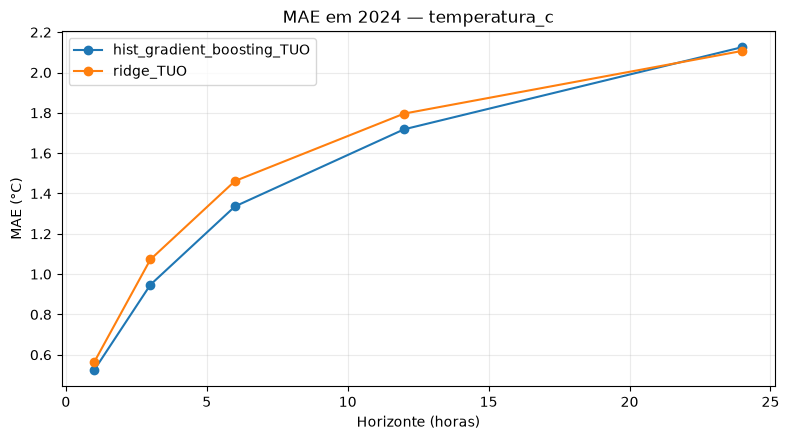

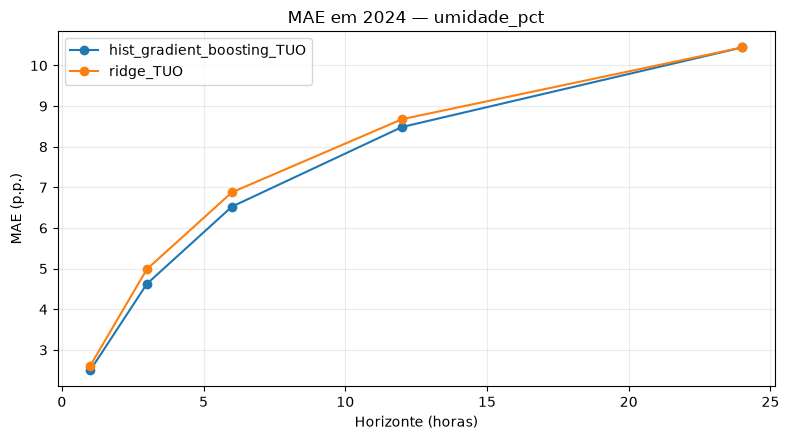

In [9]:
for alvo in ["temperatura_c","umidade_pct"]:
 d=metricas[(metricas.split=="validacao")&(metricas.alvo==alvo)]
 fig,ax=plt.subplots(figsize=(8,4.5))
 for nome,g in d.groupby("modelo"): ax.plot(g.horizonte_horas,g.mae,marker="o",label=nome)
 unidade=ALVOS[0][1] if alvo=="temperatura_c" else ALVOS[1][1]
 ax.set(title=f"MAE em 2024 — {alvo}",xlabel="Horizonte (horas)",ylabel=f"MAE ({unidade})")
 ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

## 10. Decisão de expansão para 48 modelos

A expansão será recomendada se, em 2024:

1. o ganho médio de MAE do HGB sobre a Ridge for positivo;
2. houver ganho em pelo menos 7 das 10 combinações alvo × horizonte;
3. nenhuma combinação piorar mais de 5%.

Essa decisão apenas autoriza treinar a versão horária completa. O teste de 2025 não interfere.

In [10]:
val=comparacao[comparacao.split=="validacao"]
ganho_medio=val.ganho_mae_hgb_pct.mean()
n_ganhos=int((val.ganho_mae_hgb_pct>0).sum())
pior_resultado=val.ganho_mae_hgb_pct.min()
EXPANDIR_48=bool(ganho_medio>0 and n_ganhos>=7 and pior_resultado>=-5.0)
print(f"Ganho médio de MAE em 2024: {ganho_medio:.3f}%")
print(f"Combinações com ganho: {n_ganhos}/10")
print(f"Pior diferença: {pior_resultado:.3f}%")
print("RECOMENDAÇÃO:","EXPANDIR HGB PARA 48 MODELOS" if EXPANDIR_48 else "NÃO EXPANDIR HGB")

Ganho médio de MAE em 2024: 4.960%
Combinações com ganho: 8/10
Pior diferença: -0.881%
RECOMENDAÇÃO: EXPANDIR HGB PARA 48 MODELOS


## 11. Salvamento e verificação final

In [11]:
resultados.to_csv(DIRETORIO_SAIDA/"treinamentos_hgb.csv",index=False,encoding="utf-8-sig")
criterios.to_csv(DIRETORIO_SAIDA/"selecao_configuracao_hgb_2024.csv",index=False,encoding="utf-8-sig")
metricas.to_csv(DIRETORIO_SAIDA/"metricas_hgb_vs_ridge.csv",index=False,encoding="utf-8-sig")
comparacao.to_csv(DIRETORIO_SAIDA/"comparacao_hgb_vs_ridge.csv",index=False,encoding="utf-8-sig")
for h in HORIZONTES:
 for j,(alvo,_) in ALVOS.items(): joblib.dump(modelos_candidatos[(MELHOR_CONFIG,h,j)],DIRETORIO_SAIDA/f"modelo_hgb_{alvo}_h{h}.joblib")
meta={"modelo":"HistGradientBoostingRegressor","configuracao_atributos":"TUO","melhor_configuracao_hgb":MELHOR_CONFIG,
 "horizontes_triagem":HORIZONTES,"expandir_para_48_modelos":EXPANDIR_48,"ganho_medio_mae_validacao_pct":float(ganho_medio),
 "combinacoes_com_ganho":n_ganhos,"usa_covariaveis_meteorologicas_futuras":False,"processamento":"CPU",
 "versoes":{"python":sys.version.split()[0],"numpy":np.__version__,"pandas":pd.__version__,"plataforma":platform.platform()}}
with (DIRETORIO_SAIDA/"metadados_hgb.json").open("w",encoding="utf-8") as f: json.dump(meta,f,ensure_ascii=False,indent=2)
assert np.isfinite(metricas[["mae","rmse","vies"]].to_numpy()).all()
assert meta["usa_covariaveis_meteorologicas_futuras"] is False
print("VERIFICAÇÃO FINAL: OK")
print("Decisão:","EXPANDIR HGB PARA 48 MODELOS" if EXPANDIR_48 else "NÃO EXPANDIR HGB")

VERIFICAÇÃO FINAL: OK
Decisão: EXPANDIR HGB PARA 48 MODELOS


## Encerramento

Envie `selecao_configuracao_hgb_2024.csv`, `comparacao_hgb_vs_ridge.csv` e `metricas_hgb_vs_ridge.csv` para revisão. Se a expansão for aprovada, o notebook seguinte treinará os 48 estimadores horários e salvará um pacote único para a futura API.